In [1]:
import pandas as pd
import  numpy as np
import  matplotlib.pyplot as plt

df = pd.read_csv("https://gitee.com/myles2019/dataset/raw/master/jetrail/jetrail_train.csv")
df.tail()

,ID,Datetime,Count
18283,18283,25-09-2014 19:00,868
18284,18284,25-09-2014 20:00,732
18285,18285,25-09-2014 21:00,702
18286,18286,25-09-2014 22:00,580
18287,18287,25-09-2014 23:00,534


In [2]:
df.head()

,ID,Datetime,Count
0,0,25-08-2012 00:00,8
1,1,25-08-2012 01:00,2
2,2,25-08-2012 02:00,6
3,3,25-08-2012 03:00,2
4,4,25-08-2012 04:00,2


In [3]:
df1 = pd.read_csv("https://gitee.com/myles2019/dataset/raw/master/jetrail/jetrail_train.csv", nrows=11856)

train = df1[0: 10392]
test = df1[10392:]

In [4]:
train

,ID,Datetime,Count
0,0,25-08-2012 00:00,8
1,1,25-08-2012 01:00,2
2,2,25-08-2012 02:00,6
3,3,25-08-2012 03:00,2
4,4,25-08-2012 04:00,2
...,...,...,...
10387,10387,31-10-2013 19:00,184
10388,10388,31-10-2013 20:00,190
10389,10389,31-10-2013 21:00,166
10390,10390,31-10-2013 22:00,150


In [5]:
test

,ID,Datetime,Count
10392,10392,01-11-2013 00:00,170
10393,10393,01-11-2013 01:00,156
10394,10394,01-11-2013 02:00,90
10395,10395,01-11-2013 03:00,88
10396,10396,01-11-2013 04:00,54
...,...,...,...
11851,11851,31-12-2013 19:00,286
11852,11852,31-12-2013 20:00,256
11853,11853,31-12-2013 21:00,228
11854,11854,31-12-2013 22:00,216


In [11]:
# 1. 处理 Datetime 列：强制转换，无效值设为 NaT，再删除异常行
df1['Datetime'] = pd.to_datetime(df1['Datetime'], format='%d-%m-%Y %H:%M', errors='coerce')
df1 = df1.dropna(subset=['Datetime'])  # 删除时间无效的行

# 2. 设置 datetime 索引
df1.index = df1['Datetime']

# 3. 只对数值列重采样求均值（关键：排除非数值列）
df1_cols = df1.select_dtypes(include=['int64', 'float64']).columns
df1 = df1[df1_cols].resample('D').mean()

# 查看结果
df1.head()

,ID,Count
Datetime,,
2012-08-25,11.5,3.166667
2012-08-26,35.5,3.666667
2012-08-27,59.5,2.583333
2012-08-28,83.5,2.416667
2012-08-29,107.5,2.500000


In [12]:
# 1. 处理 Datetime 列：强制转换，无效值设为 NaT，再删除异常行
train['Datetime'] = pd.to_datetime(train['Datetime'], format='%d-%m-%Y %H:%M', errors='coerce')
train = train.dropna(subset=['Datetime'])  # 删除时间无效的行

# 2. 设置 datetime 索引
train.index = train['Datetime']

# 3. 只对数值列重采样求均值（关键：排除非数值列）
train_cols = train.select_dtypes(include=['int64', 'float64']).columns
train = train[train_cols].resample('D').mean()

# 查看结果
train.head()

,ID,Count
Datetime,,
2012-08-25,11.5,3.166667
2012-08-26,35.5,3.666667
2012-08-27,59.5,2.583333
2012-08-28,83.5,2.416667
2012-08-29,107.5,2.500000


In [13]:
# 1. 处理 Datetime 列：强制转换，无效值设为 NaT，再删除异常行
test['Datetime'] = pd.to_datetime(test['Datetime'], format='%d-%m-%Y %H:%M', errors='coerce')
test = test.dropna(subset=['Datetime'])  # 删除时间无效的行

# 2. 设置 datetime 索引
test.index = test['Datetime']

# 3. 只对数值列重采样求均值（关键：排除非数值列）
test_cols = test.select_dtypes(include=['int64', 'float64']).columns
test = test[test_cols].resample('D').mean()

# 查看结果
test.head()

,ID,Count
Datetime,,
2013-11-01,10403.5,161.583333
2013-11-02,10427.5,103.083333
2013-11-03,10451.5,76.833333
2013-11-04,10475.5,156.416667
2013-11-05,10499.5,169.750000


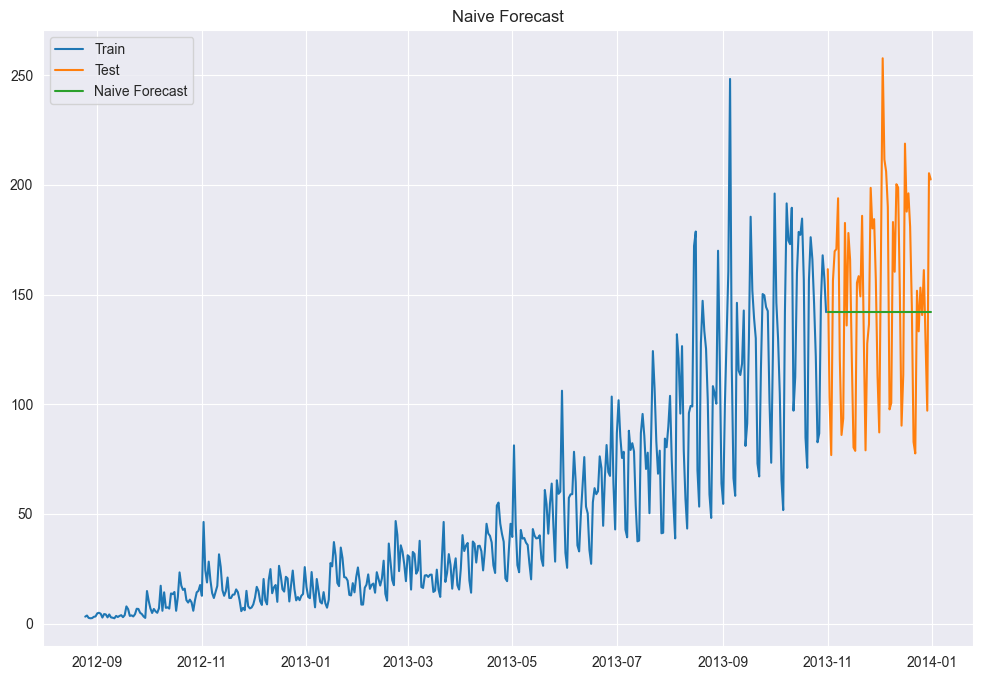

In [15]:
dd = np.asarray(train.Count)
y_hat = test.copy()
y_hat['naive'] = dd[len(dd)-1]

plt.figure(figsize=(12, 8))
plt.plot(train.index, train['Count'], label = 'Train')
plt.plot(test.index, test['Count'], label = 'Test')
plt.plot(y_hat.index, y_hat['naive'], label = 'Naive Forecast')
plt.legend(loc = 'best')
plt.title('Naive Forecast')
plt.show()

In [16]:
from sklearn.metrics import mean_squared_error
from math import sqrt

rms = sqrt(mean_squared_error(test.Count, y_hat.naive))
rms

43.91640614391676

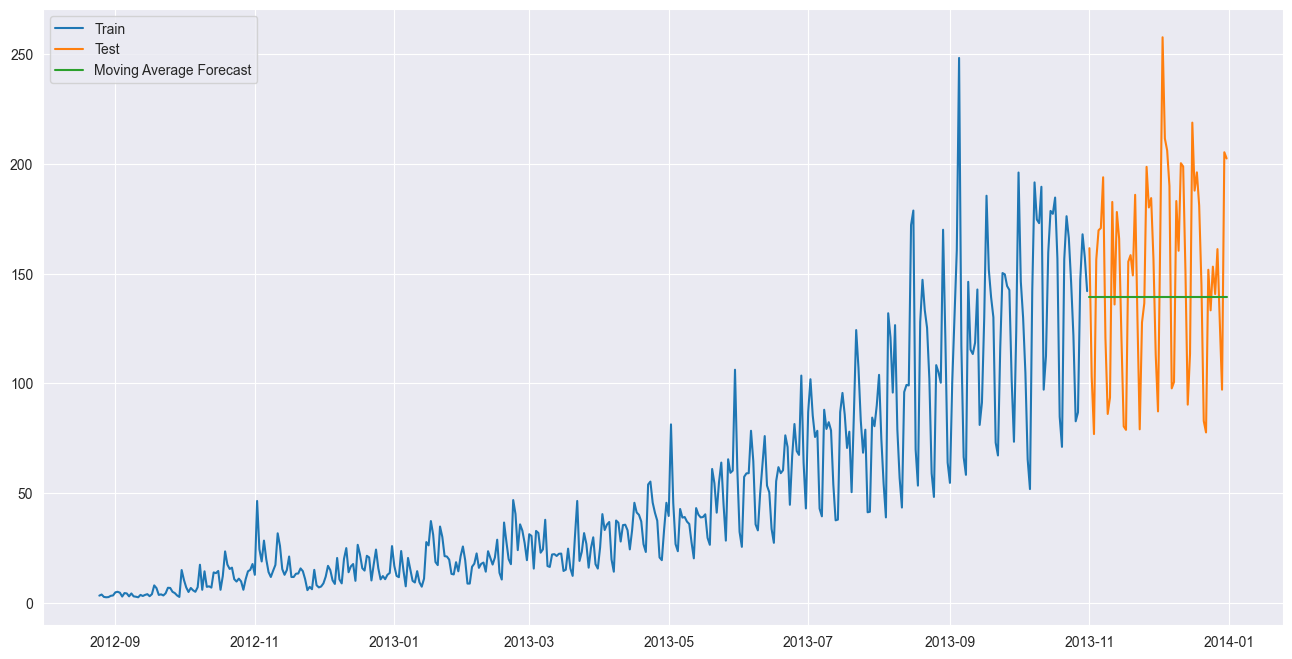

In [21]:
y_hat_avg = test.copy()
y_hat_avg['moving_avg_forecast'] = train['Count'].rolling(10).mean().iloc[-1]

plt.figure(figsize=(16, 8))
plt.plot(train['Count'], label = 'Train')
plt.plot(test['Count'], label = 'Test')
plt.plot(y_hat_avg['moving_avg_forecast'], label = 'Moving Average Forecast')
plt.legend(loc = 'best')
plt.show()

In [20]:
rms_moving = sqrt(mean_squared_error(test.Count, y_hat_avg.moving_avg_forecast))
rms_moving

44.424268667365105

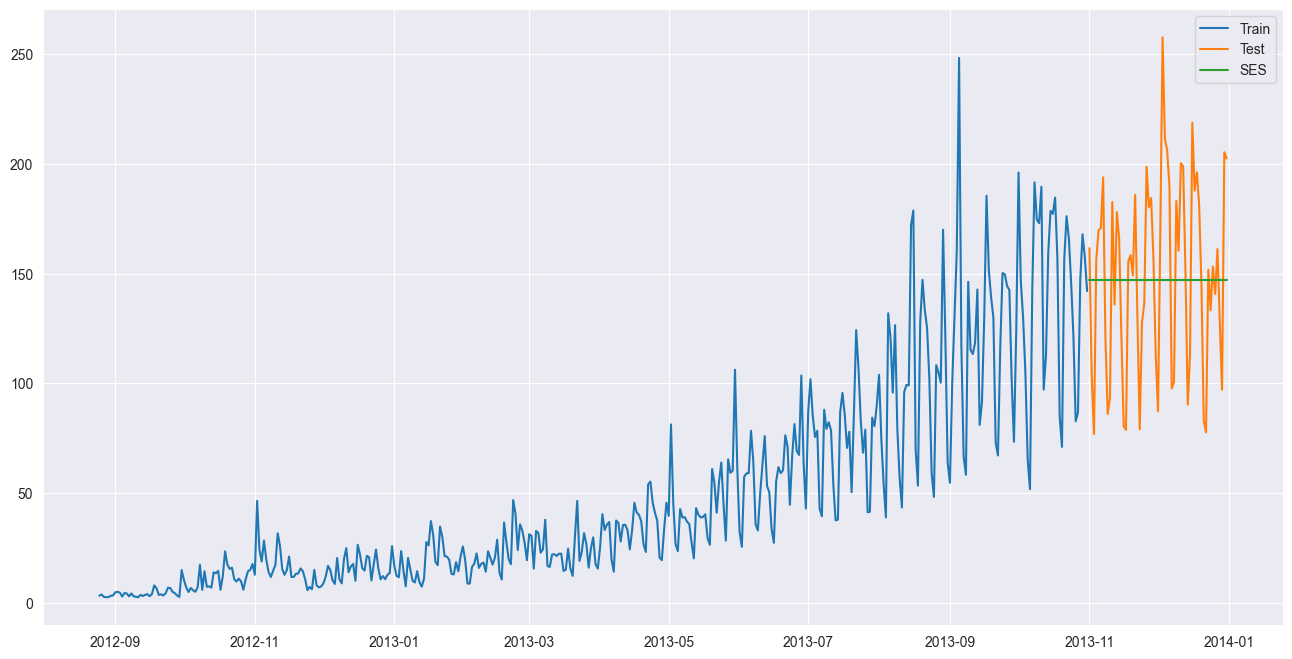

In [30]:
from statsmodels.tsa.api import SimpleExpSmoothing
y_hat_avg_SES = test.copy()
fit2 = SimpleExpSmoothing(np.asarray(train['Count'])).fit(smoothing_level=0.6, optimized=False)

y_hat_avg_SES['SES'] = fit2.forecast(len(test))
plt.figure(figsize=(16, 8))
plt.plot(train['Count'], label = 'Train')
plt.plot(test['Count'], label = 'Test')
plt.plot(y_hat_avg_SES['SES'], label = 'SES')
plt.legend(loc = 'best')
plt.show()

In [25]:
rms_SES = sqrt(mean_squared_error(test.Count, y_hat_avg_SES.SES))
rms_SES

43.357625225228155

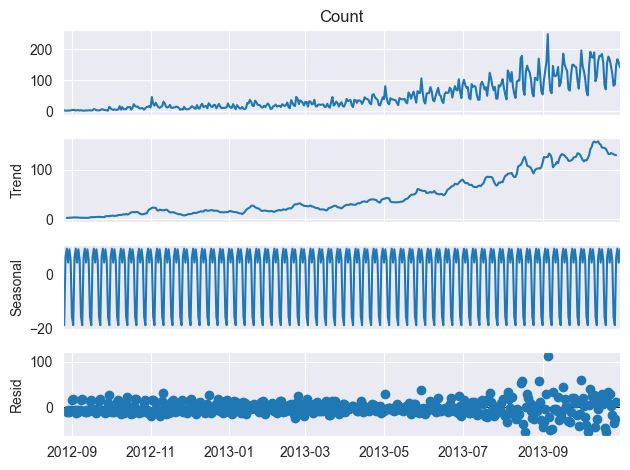

In [26]:
import  statsmodels.api as sm
sm.tsa.seasonal_decompose(train.Count).plot()
result = sm.tsa.stattools.adfuller(train.Count)
plt.show()

D:\Anaconda3\Anaconda\envs\lisc\lib\site-packages\pandas\util\_decorators.py:213: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)


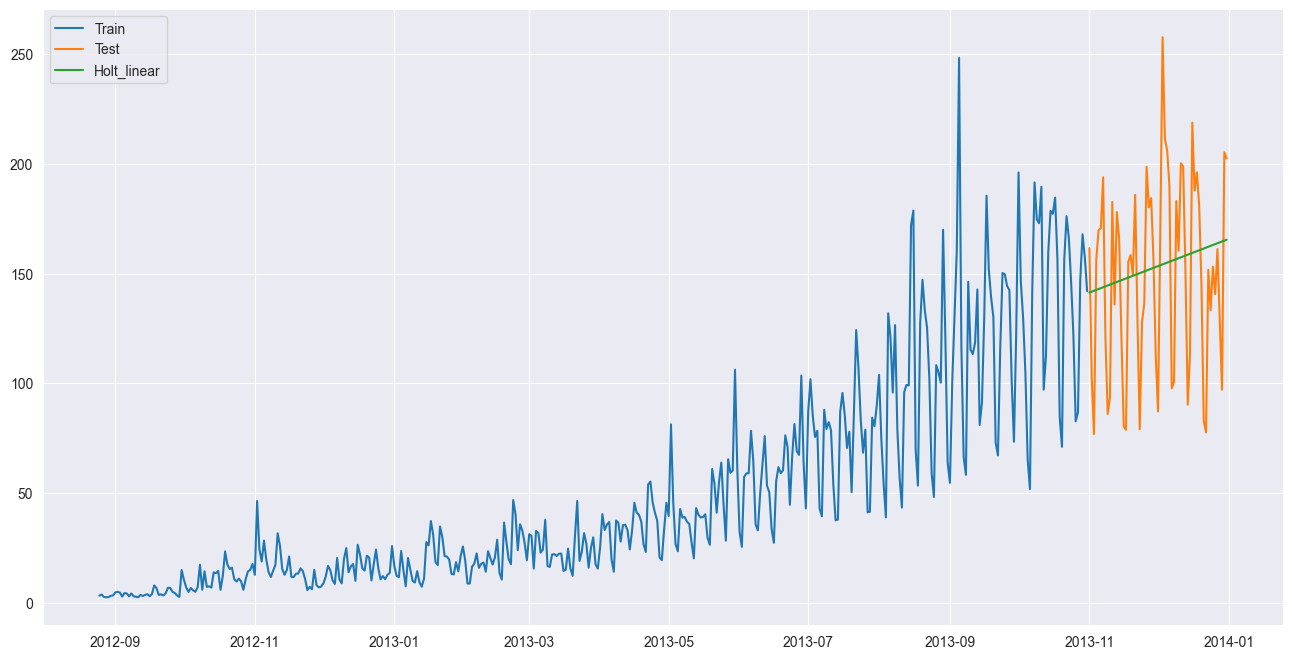

In [29]:
from statsmodels.tsa.api import ExponentialSmoothing, SimpleExpSmoothing, Holt
y_hat_avg_Holt = test.copy()
fit1 = Holt(np.asarray(train['Count'])).fit(smoothing_level=0.3, smoothing_trend = 0.1)
y_hat_avg_Holt['Holt_linear'] = fit1.forecast(len(test))

plt.figure(figsize=(16, 8))
plt.plot(train['Count'], label = 'Train')
plt.plot(test['Count'], label = 'Test')
plt.plot(y_hat_avg_Holt['Holt_linear'], label = 'Holt_linear')
plt.legend(loc = 'best')
plt.show()

In [31]:
rms_Holt = sqrt(mean_squared_error(test.Count, y_hat_avg_Holt.Holt_linear))
rms_Holt

43.056259611507286

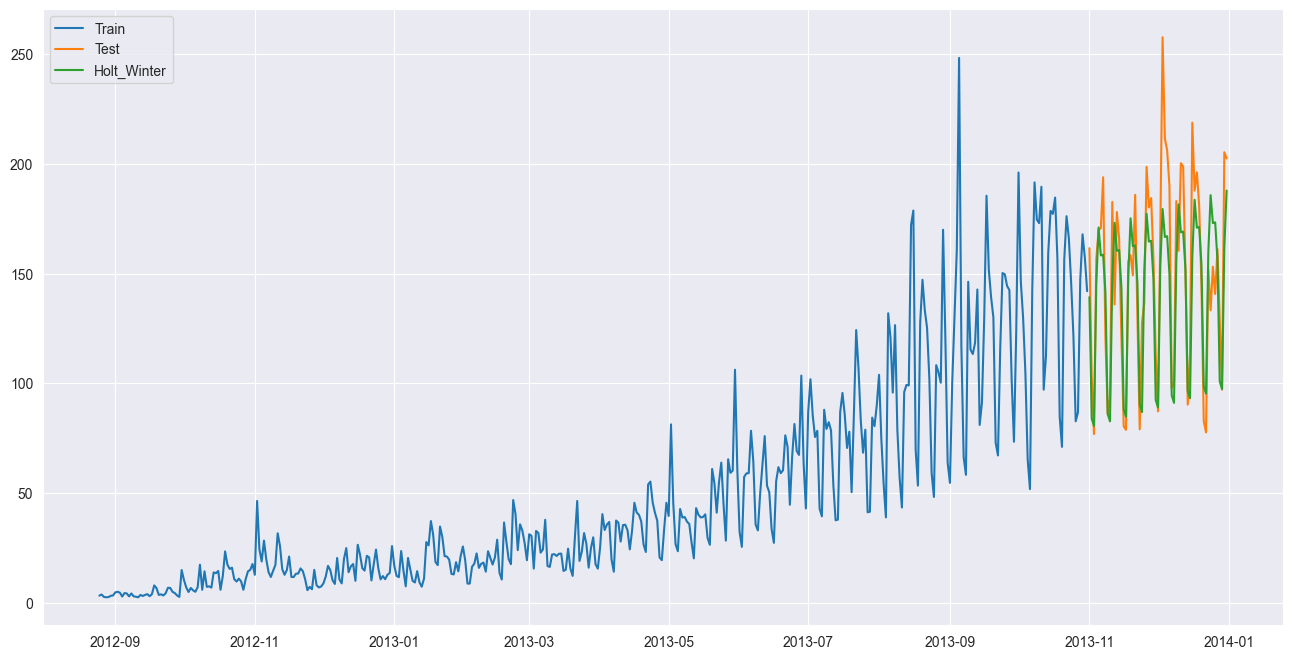

In [33]:
from statsmodels.tsa.api import ExponentialSmoothing
y_hat_avg_Holt_Winter = test.copy()
fit3 = ExponentialSmoothing(np.asarray(train['Count']),
                                       seasonal_periods = 7,
                                       trend = 'add',
                                       seasonal = 'add',).fit()

y_hat_avg_Holt_Winter['Holt_Winter'] = fit3.forecast(len(test))
plt.figure(figsize=(16, 8))
plt.plot(train['Count'], label = 'Train')
plt.plot(test['Count'], label = 'Test')
plt.plot(y_hat_avg_Holt_Winter['Holt_Winter'], label = 'Holt_Winter')
plt.legend(loc = 'best')
plt.show()

In [35]:
rms_Holt_Winter = sqrt(mean_squared_error(test.Count, y_hat_avg_Holt_Winter.Holt_Winter))
rms_Holt_Winter

25.26461226826601

D:\Anaconda3\Anaconda\envs\lisc\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


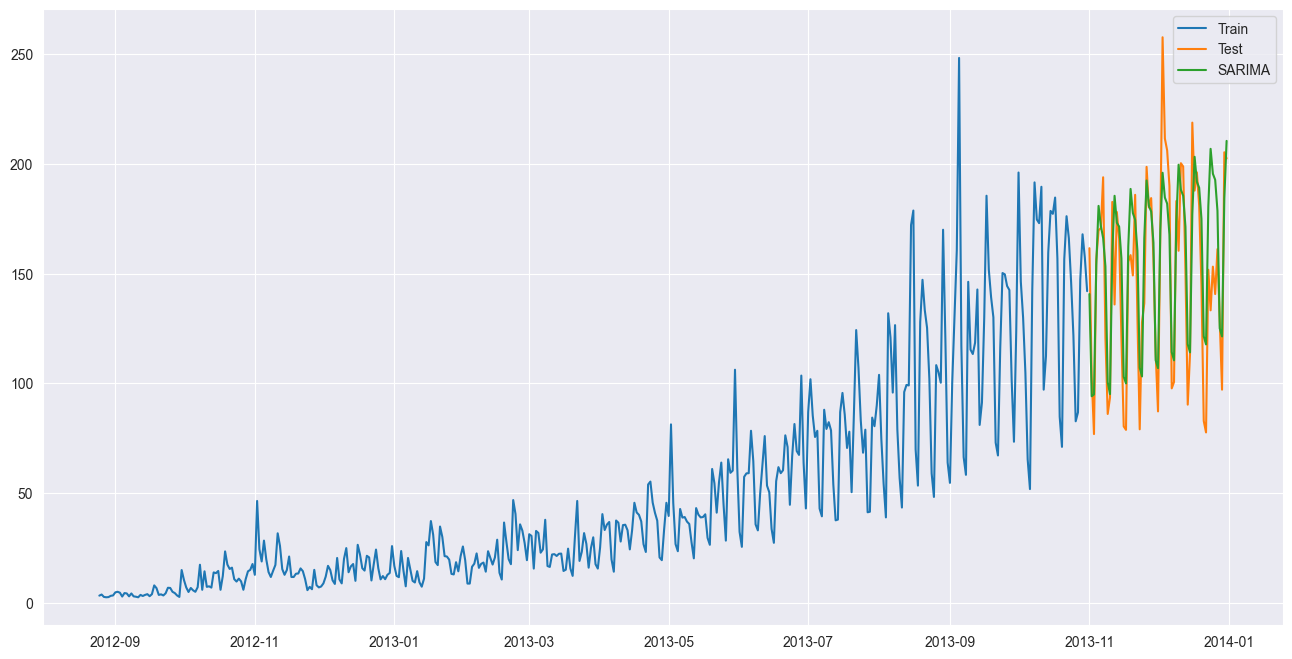

In [39]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
y_hat_avg_SARIMA = test.copy()
fit4 = SARIMAX(train.Count, order=(2, 1, 4),
                                 seasonal_order=(0,1,1,7)).fit()

y_hat_avg_SARIMA['SARIMA'] = fit4.predict(start="2013-11-1",
                                            end="2013-12-31",
                                            dynamic=True)
plt.figure(figsize=(16, 8))
plt.plot(train['Count'], label = 'Train')
plt.plot(test['Count'], label = 'Test')
plt.plot(y_hat_avg_SARIMA['SARIMA'], label = 'SARIMA')
plt.legend(loc = 'best')
plt.show()

In [40]:
rms_SARIMA = sqrt(mean_squared_error(test.Count, y_hat_avg_SARIMA.SARIMA))
rms_SARIMA

26.039195075897904